### Health Data Analysis Case Study
A detailed analysis on key healthcare metrics such as average cost, median stay duration, senior citizens, obese patients, and patients at risk.

In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [2]:
df = pd.read_csv("Healthcare_Dataset.csv")


In [3]:
#ignoring warnings
import warnings
warnings.filterwarnings("ignore")


In [4]:
pd.set_option("display.max_rows",500)
pd.set_option("display.max_columns",500)
pd.set_option("display.width",1000)
pd.set_option("display.expand_frame_repr",False)
pd.set_option('display.float_format', '{:.2f}'.format)  #rounding upto 2 decimals


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           200 non-null    object 
 1   Name                 200 non-null    object 
 2   Age                  200 non-null    int64  
 3   Gender               200 non-null    object 
 4   Height_cm            200 non-null    float64
 5   Weight_kg            200 non-null    float64
 6   BMI                  191 non-null    float64
 7   Blood_Pressure       200 non-null    object 
 8   Heart_Rate           200 non-null    int64  
 9   Cholesterol_Level    200 non-null    float64
 10  Blood_Sugar_mg/dL    200 non-null    float64
 11  Smoking_Status       184 non-null    object 
 12  Alcohol_Consumption  200 non-null    float64
 13  Physical_Activity    200 non-null    int64  
 14  Diabetes_Status      200 non-null    object 
 15  Diagnosis_Code       200 non-null    obj

In [6]:
df.isnull().sum()

Patient_ID              0
Name                    0
Age                     0
Gender                  0
Height_cm               0
Weight_kg               0
BMI                     9
Blood_Pressure          0
Heart_Rate              0
Cholesterol_Level       0
Blood_Sugar_mg/dL       0
Smoking_Status         16
Alcohol_Consumption     0
Physical_Activity       0
Diabetes_Status         0
Diagnosis_Code          0
Prescription            9
Admission_Date          0
Discharge_Date          0
Treatment_Cost          0
Doctor_Assigned        14
dtype: int64

In [7]:
#percentage of null values
df.isnull().sum()*100/len(df)

Patient_ID            0.00
Name                  0.00
Age                   0.00
Gender                0.00
Height_cm             0.00
Weight_kg             0.00
BMI                   4.50
Blood_Pressure        0.00
Heart_Rate            0.00
Cholesterol_Level     0.00
Blood_Sugar_mg/dL     0.00
Smoking_Status        8.00
Alcohol_Consumption   0.00
Physical_Activity     0.00
Diabetes_Status       0.00
Diagnosis_Code        0.00
Prescription          4.50
Admission_Date        0.00
Discharge_Date        0.00
Treatment_Cost        0.00
Doctor_Assigned       7.00
dtype: float64

In [8]:
# creating dataframe for missing BMI values
missing_rows=df[df["BMI"].isna()]
print(missing_rows)

    Patient_ID              Name  Age  Gender  Height_cm  Weight_kg  BMI Blood_Pressure  Heart_Rate  Cholesterol_Level  Blood_Sugar_mg/dL Smoking_Status  Alcohol_Consumption  Physical_Activity Diabetes_Status Diagnosis_Code                Prescription Admission_Date Discharge_Date  Treatment_Cost Doctor_Assigned
9        P1009    Joshua Burgess   59  Female     167.10      40.60  NaN         159/83          94             150.20             104.90         Smoker                17.60                  1             Yes            N18  Democratic drive consumer.     2025-06-24     2025-07-04         8114.56       Dr. Mehta
20       P1020     Marisa Garcia   72  Female     162.80      75.40  NaN         121/68          88             234.30              87.00     Non-Smoker                11.00                  6             Yes            E11            Management play.     2025-04-02     2025-04-04        44739.79        Dr. Iyer
35       P1035      Sherry Wells   90   Other     167.30  

In [9]:
l1=[]
for i in missing_rows.index:
    l1.append(i)
l1

[9, 20, 35, 48, 82, 113, 163, 177, 195]

In [10]:
# Question 32: Calculate BMI of NaN using Height and Weight
for i,j in zip(missing_rows.BMI,l1):
    w=missing_rows.loc[j,"Weight_kg"]
    h=missing_rows.loc[j,"Height_cm"]
    b=(w*10000/h**2)
    df.loc[j,"BMI"]=b

In [11]:
df["BMI"]

0     23.50
1     25.10
2     30.40
3     14.70
4     31.10
5     20.60
6     28.10
7     25.90
8     19.90
9     14.54
10    24.40
11    26.20
12    15.40
13    31.60
14    26.70
15    26.20
16    30.10
17    21.20
18    34.50
19    23.80
20    28.45
21    25.40
22    30.50
23    26.10
24    26.20
25    28.00
26    28.50
27    24.50
28    39.00
29    19.40
30    18.90
31    35.20
32    22.60
33    32.30
34    26.40
35    32.01
36    29.10
37    25.70
38    29.40
39    22.80
40    33.90
41    25.00
42    22.20
43    27.90
44    33.70
45    19.50
46    30.40
47    19.30
48    18.37
49    29.60
50    27.60
51    24.50
52    44.10
53    26.20
54    26.80
55    11.90
56    33.60
57    32.20
58    22.00
59    34.80
60    27.70
61    27.80
62    22.80
63    24.70
64    18.80
65    28.50
66    19.40
67    27.90
68    22.50
69    21.90
70    29.00
71    11.70
72    21.60
73    32.70
74    24.60
75    25.10
76    26.40
77    23.00
78    27.40
79    22.10
80    28.60
81    21.60
82    27.09
83  

In [12]:
# Since the datatype of Prescription, Smoking_Status and Doctor_Assigned is object, we fill the null values with mode
l=["Prescription","Doctor_Assigned","Smoking_Status"]
for i in l:
    df[i]=df[i].fillna(df[i].mode()[0])
    

In [13]:
df.describe(include='all')

,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned
count,200,200,200.00,200,200.00,200.00,200.00,200,200.00,200.00,200.00,200,200.00,200.00,200,200,200,200,200,200.00,200
unique,200,199,NaN,3,NaN,NaN,NaN,195,NaN,NaN,NaN,3,NaN,NaN,2,6,191,81,84,NaN,5
top,P1000,Michael King,NaN,Female,NaN,NaN,NaN,114/69,NaN,NaN,NaN,Former,NaN,NaN,Yes,N18,About this such range.,2025-06-23,2025-06-11,NaN,Dr. Sharma
freq,1,2,NaN,72,NaN,NaN,NaN,2,NaN,NaN,NaN,93,NaN,NaN,109,42,10,7,7,NaN,56
mean,NaN,NaN,54.63,NaN,164.36,69.91,26.17,NaN,88.70,190.28,100.72,NaN,9.77,3.65,NaN,NaN,NaN,NaN,NaN,28007.15,NaN
std,NaN,NaN,20.94,NaN,9.04,14.59,6.41,NaN,18.79,31.78,24.94,NaN,5.82,2.33,NaN,NaN,NaN,NaN,NaN,12826.24,NaN
min,NaN,NaN,18.00,NaN,138.50,40.60,11.70,NaN,55.00,92.80,42.50,NaN,0.10,0.00,NaN,NaN,NaN,NaN,NaN,5051.80,NaN
25%,NaN,NaN,35.75,NaN,157.97,59.72,21.55,NaN,72.00,169.82,81.90,NaN,4.95,2.00,NaN,NaN,NaN,NaN,NaN,17259.00,NaN
50%,NaN,NaN,56.00,NaN,164.85,69.00,25.80,NaN,89.00,190.75,100.70,NaN,9.25,4.00,NaN,NaN,NaN,NaN,NaN,28382.89,NaN
75%,NaN,NaN,71.25,NaN,170.05,79.22,29.65,NaN,107.00,209.45,118.90,NaN,14.83,6.00,NaN,NaN,NaN,NaN,NaN,39642.79,NaN


In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
# Converting Admission_Date and Discharge_Date columns to datetime format
df["Admission_Date"]=pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"]=pd.to_datetime(df["Discharge_Date"])


In [16]:
# Extracting systolic and diastolic pressure into new columns

sys=[]
dia=[]
for i in df.Blood_Pressure:
    i=str(i)
    x=i.split("/")
    sys.append(x[0])
    dia.append(x[1])
df["Systolic"]= sys
df["Diastolic"]=dia
df["Systolic"]= pd.to_numeric(df['Systolic'], errors='coerce')
df["Diastolic"]= pd.to_numeric(df['Diastolic'], errors='coerce')


In [17]:
# Standardize 'Gender' values (e.g., M, MALE → Male)
df["Gender"].value_counts()

Gender
Female    72
Other     66
Male      62
Name: count, dtype: int64

In [18]:
# Remove rows with negative Age
df=df[df["Age"]>0]


In [19]:
# Remove outliers in BMI using IQR method
q1=df["BMI"].quantile(0.25)
q3=df["BMI"].quantile(0.75)
IQR=q3-q1
LB=q1-1.5*IQR
UB=q3+1.5*IQR
for i in df.BMI:
    if i>UB or i<LB:
        df=df[~(df["BMI"]==i)]

In [20]:
# Remove records with Heart Rate > 220
df=df[~(df["Heart_Rate"]>220)]

In [21]:
# Convert 'Height_cm' and 'Weight_kg' to float
df[["Height_cm","Weight_kg"]].dtypes

Height_cm    float64
Weight_kg    float64
dtype: object

In [22]:
# Validate Diagnosis_Code (should be alphanumeric)
df = df[df['Diagnosis_Code'].str.match(r'^[A-Z]\d{2}$')]


In [23]:
# Replace 'N/A' strings with NaN
df.replace("N/A",np.nan,inplace=True)


In [24]:
#Replace empty strings with NaN
df.replace("", np.nan, regex=True, inplace=True)

In [25]:
# Create Stay_Duration column from dates
df["Stay_Duration"]=(df["Discharge_Date"]-df["Admission_Date"]).dt.days

In [26]:
# Flag patients with high BP (Systolic > 140 or Diastolic > 90)
df["High_BP"]= ((df["Systolic"]>140) | (df["Diastolic"]>90))

In [27]:
# Mark Cholesterol > 240 as 'High'
df["Cholestrol_category"]=df["Cholesterol_Level"].apply(lambda x:"High" if x>250 else "Normal")

In [28]:
# Flag senior citizens (Age > 60)
df["Flag_age"]=df["Age"]>60

In [29]:
# Cost per day = Treatment_Cost / Stay_Duration
df["Cost_per_day"]=df["Treatment_Cost"]/df["Stay_Duration"]

In [30]:
# Round BMI to 1 decimal
df["BMI"]=df["BMI"].round(1)

In [31]:
# Encode Diabetes_Status to binary
df["Diabetes_Status"]=df["Diabetes_Status"].map({"Yes":1,"No":0})

In [32]:
df["BMI"]

0     23.50
1     25.10
2     30.40
3     14.70
4     31.10
5     20.60
6     28.10
7     25.90
8     19.90
9     14.50
10    24.40
11    26.20
12    15.40
13    31.60
14    26.70
15    26.20
16    30.10
17    21.20
18    34.50
19    23.80
20    28.40
21    25.40
22    30.50
23    26.10
24    26.20
25    28.00
26    28.50
27    24.50
28    39.00
29    19.40
30    18.90
31    35.20
32    22.60
33    32.30
34    26.40
35    32.00
36    29.10
37    25.70
38    29.40
39    22.80
40    33.90
41    25.00
42    22.20
43    27.90
44    33.70
45    19.50
46    30.40
47    19.30
48    18.40
49    29.60
50    27.60
51    24.50
53    26.20
54    26.80
55    11.90
56    33.60
57    32.20
58    22.00
59    34.80
60    27.70
61    27.80
62    22.80
63    24.70
64    18.80
65    28.50
66    19.40
67    27.90
68    22.50
69    21.90
70    29.00
71    11.70
72    21.60
73    32.70
74    24.60
75    25.10
76    26.40
77    23.00
78    27.40
79    22.10
80    28.60
81    21.60
82    27.10
83    21.80
84  

In [33]:
# Categorize Obesity using BMI ranges
for i,j in zip(df.BMI,range(0,len(df)+1,1)):
    if i>=30:
        df.loc[j,"BMI_Category"]="Obese"
    elif i>=25:
        df.loc[j,"BMI_Category"]="Overweight"
    elif i>=18.5:
        df.loc[j,"BMI_Category"]="Healthy Weight"
    else:
        df.loc[j,"BMI_Category"]="UnderWeight"

In [34]:
df["BMI_Category"]

0      Healthy Weight
1          Overweight
2               Obese
3         UnderWeight
4               Obese
5      Healthy Weight
6          Overweight
7          Overweight
8      Healthy Weight
9         UnderWeight
10     Healthy Weight
11         Overweight
12        UnderWeight
13              Obese
14         Overweight
15         Overweight
16              Obese
17     Healthy Weight
18              Obese
19     Healthy Weight
20         Overweight
21         Overweight
22              Obese
23         Overweight
24         Overweight
25         Overweight
26         Overweight
27     Healthy Weight
28              Obese
29     Healthy Weight
30     Healthy Weight
31              Obese
32     Healthy Weight
33              Obese
34         Overweight
35              Obese
36         Overweight
37         Overweight
38         Overweight
39     Healthy Weight
40              Obese
41         Overweight
42     Healthy Weight
43         Overweight
44              Obese
45     Hea

In [35]:
# Create a risk flag for patients with diabetes, high cholesterol, and age > 60
df["Flag_Dia_Chol_Age"]=((df["Diabetes_Status"]==1)&(df["Flag_age"]==True)&(df["Cholestrol_category"]=="High"))
df["Flag_Dia_Chol_Age"]

0      False
1      False
2      False
3      False
4      False
5      False
6      False
7      False
8      False
9      False
10     False
11     False
12     False
13     False
14     False
15     False
16     False
17     False
18     False
19     False
20     False
21     False
22     False
23     False
24     False
25     False
26     False
27     False
28     False
29     False
30     False
31     False
32     False
33     False
34     False
35     False
36     False
37     False
38     False
39     False
40     False
41     False
42     False
43     False
44     False
45     False
46     False
47     False
48     False
49     False
50     False
51     False
53     False
54     False
55     False
56     False
57     False
58     False
59     False
60     False
61     False
62     False
63     False
64     False
65     False
66     False
67     False
68     False
69     False
70     False
71     False
72     False
73     False
74     False
75     False
76     False
77     False

In [36]:
# mean BMI using NumPy
np.mean(df['BMI'])

np.float64(25.710769230769234)

In [37]:
#standard deviation of Age using NumPy.
np.std(df["Age"])

20.990292988355716

In [38]:
#90th percentile of Treatment_Cost.
np.percentile(df['Treatment_Cost'], 90)

np.float64(nan)

In [39]:
# Heart_Rate column to a NumPy array.
np.array(df["Heart_Rate"])


array([ 72.,  83.,  88.,  92.,  76.,  95., 118.,  69.,  93.,  94., 109.,
        84., 115.,  86.,  66., 117.,  63.,  88.,  63.,  74.,  88.,  60.,
       107.,  99.,  97., 104.,  95.,  93., 120.,  79., 114., 109.,  85.,
        81.,  89.,  72.,  61.,  82.,  86.,  68.,  89.,  82., 112.,  94.,
        91.,  68.,  61., 109., 115.,  89., 110.,  90., 111., 107., 113.,
       117.,  60.,  67., 103.,  67.,  76.,  75.,  92., 100.,  77.,  83.,
        68.,  93., 107., 113.,  97.,  96.,  60.,  73.,  82.,  65.,  91.,
        58.,  73.,  75., 117.,  77., 108.,  65.,  85.,  96.,  62.,  62.,
       107.,  99.,  66., 119.,  85., 119.,  89., 102.,  57., 119.,  68.,
       113., 100., 102., 112., 120.,  74.,  70.,  99.,  85.,  64.,  70.,
        93.,  88.,  75.,  85.,  79., 118., 101.,  80.,  75.,  94., 103.,
        72.,  93.,  99.,  72.,  55.,  77.,  97.,  98., 116.,  70., 108.,
        69., 113.,  63., 103., 109.,  85.,  95., 109., 114.,  61.,  82.,
        94.,  57., 117.,  64., 116.,  74.,  59.,  8

In [40]:
# Count the number of patients with BMI over 30 using NumPy.
np.sum(df["BMI"]>30)

np.int64(43)

In [41]:
# Calculate average Treatment_Cost by Gender.
df.groupby('Gender')['Treatment_Cost'].mean()

Gender
Female   26938.20
Male     31191.99
Other    26614.89
Name: Treatment_Cost, dtype: float64

In [42]:
# Count the number of patients for each Smoking_Status
df['Smoking_Status'].value_counts()

Smoking_Status
Former        89
Smoker        55
Non-Smoker    51
Name: count, dtype: int64

In [43]:
# median Treatment_Cost per Doctor_Assigned.
df.groupby("Doctor_Assigned")["Treatment_Cost"].median()

Doctor_Assigned
Dr. Iyer     31204.17
Dr. Kapoor   23791.79
Dr. Mehta    23476.57
Dr. Roy      25751.75
Dr. Sharma   35314.72
Name: Treatment_Cost, dtype: float64

In [44]:
# High risk patients per doctor
df[df["Flag_Dia_Chol_Age"]].groupby("Doctor_Assigned")["Patient_ID"].count()

Doctor_Assigned
Dr. Kapoor    1
Dr. Mehta     2
Name: Patient_ID, dtype: int64

In [45]:
# Avg stay per diagnosis
df.groupby("Diagnosis_Code")["Stay_Duration"].mean()

Diagnosis_Code
E11   8.84
I10   8.62
J45   9.17
K21   8.17
M54   8.27
N18   7.64
Name: Stay_Duration, dtype: float64

In [46]:
# Heart Rate > 100
df[df["Heart_Rate"]>100]

,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age
6,P1006,Melissa Taylor,69.00,Female,159.60,71.70,28.10,108/92,118.00,155.50,109.40,Former,0.90,1.00,1.00,N18,Bill star.,2025-06-06,2025-06-13,35621.65,Dr. Kapoor,108.00,92.00,7.00,True,Normal,True,5088.81,Overweight,False
10,P1010,Tim Alvarez,78.00,Other,172.40,72.60,24.40,133/98,109.00,186.50,92.50,Former,15.10,3.00,0.00,K21,Look same.,2025-05-04,2025-05-07,34244.51,Dr. Iyer,133.00,98.00,3.00,True,Normal,True,11414.84,Healthy Weight,False
12,P1012,Jeremy Aguilar,53.00,Other,168.40,43.60,15.40,134/68,115.00,199.70,90.40,Non-Smoker,16.10,3.00,1.00,E11,Employee reason.,2025-04-23,2025-04-27,20943.39,Dr. Sharma,134.00,68.00,4.00,False,Normal,False,5235.85,UnderWeight,False
15,P1015,Donald Williams,51.00,Female,160.20,67.20,26.20,144/95,117.00,156.80,70.10,Non-Smoker,4.40,0.00,1.00,N18,Somebody home relationship.,2025-03-27,2025-04-03,7256.41,Dr. Iyer,144.00,95.00,7.00,True,Normal,False,1036.63,Overweight,False
22,P1022,Deanna Howell,37.00,Male,159.70,77.70,30.50,151/71,107.00,192.90,124.20,Former,14.70,5.00,0.00,N18,Good future.,2025-05-17,2025-05-27,41483.72,Dr. Sharma,151.00,71.00,10.00,True,Normal,False,4148.37,Obese,False
25,P1025,Seth Cobb,58.00,Female,150.80,63.70,28.00,132/67,104.00,179.70,79.90,Smoker,5.10,6.00,1.00,M54,Mind say feel late.,2025-04-10,2025-04-16,29230.34,Dr. Mehta,132.00,67.00,6.00,False,Normal,False,4871.72,Overweight,False
28,P1028,Renee Martin,78.00,Other,165.60,106.90,39.00,105/78,120.00,184.20,107.50,Former,6.70,3.00,0.00,I10,Security already.,2025-04-15,2025-04-24,11630.93,Dr. Sharma,105.00,78.00,9.00,False,Normal,True,1292.33,Obese,False
30,P1030,Melissa Henderson,72.00,Male,172.90,56.40,18.90,144/93,114.00,232.10,65.00,Former,5.00,1.00,0.00,I10,Thing.,2025-05-05,2025-05-18,35041.00,Dr. Iyer,144.00,93.00,13.00,True,Normal,True,2695.46,Healthy Weight,False
31,P1031,James Bernard,74.00,Other,170.90,102.90,35.20,157/92,109.00,160.30,85.80,Former,8.90,2.00,0.00,K21,Capital hold.,2025-06-05,2025-06-11,16125.79,Dr. Iyer,157.00,92.00,6.00,True,Normal,True,2687.63,Obese,False
42,P1042,Louis Rivera,48.00,Other,162.50,58.70,22.20,145/91,112.00,163.30,79.60,Smoker,5.90,6.00,1.00,J45,The position.,2025-04-18,2025-04-27,21605.92,Dr. Roy,145.00,91.00,9.00,True,Normal,False,2400.66,Healthy Weight,False


In [47]:
#  diabetic patients under 40 years old
df[((df["Diabetes_Status"]==1)&(df["Age"]<40))]

,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age
5,P1005,Cheryl Wright,22.00,Female,179.70,66.60,20.60,104/73,95.00,192.00,64.40,Non-Smoker,7.90,7.00,1.00,J45,Skill.,2025-05-04,2025-05-08,38524.50,Dr. Iyer,104.00,73.00,4.00,False,Normal,False,9631.12,Healthy Weight,False
11,P1011,Janet Hernandez,33.00,Male,150.20,59.20,26.20,121/61,84.00,176.20,126.40,Smoker,1.40,0.00,1.00,E11,Physical deal machine.,2025-05-09,2025-05-17,43683.59,Dr. Sharma,121.00,61.00,8.00,False,Normal,False,5460.45,Overweight,False
13,P1013,Michele Hughes,30.00,Male,158.20,79.20,31.60,121/66,86.00,220.90,123.30,Former,9.00,6.00,1.00,J45,Well employee.,2025-05-14,2025-05-25,44351.87,Dr. Sharma,121.00,66.00,11.00,False,Normal,False,4031.99,Obese,False
16,P1016,Rodney Dixon MD,25.00,Other,173.10,90.30,30.10,111/64,63.00,187.80,125.10,Smoker,8.10,3.00,1.00,M54,Until region.,2025-06-23,2025-06-26,34581.79,Dr. Roy,111.00,64.00,3.00,False,Normal,False,11527.26,Obese,False
19,P1019,Andrew Burton,31.00,Male,165.90,65.50,23.80,156/66,74.00,192.80,50.30,Former,4.20,5.00,1.00,N18,Audience song.,2025-06-23,2025-06-28,16879.28,Dr. Sharma,156.00,66.00,5.00,True,Normal,False,3375.86,Healthy Weight,False
29,P1029,Hunter Fitzgerald,27.00,Female,164.70,52.50,19.40,140/96,79.00,224.30,118.80,Non-Smoker,9.90,3.00,1.00,N18,Former research along.,2025-05-23,2025-05-31,45169.69,Dr. Sharma,140.00,96.00,8.00,True,Normal,False,5646.21,Healthy Weight,False
41,P1041,Anna Young,21.00,Female,174.60,76.20,25.00,111/91,82.00,214.70,147.40,Non-Smoker,6.80,4.00,1.00,M54,Watch.,2025-05-14,2025-05-20,8852.58,Dr. Kapoor,111.00,91.00,6.00,True,Normal,False,1475.43,Overweight,False
46,P1046,Diamond Hall,26.00,Female,162.80,80.70,30.40,136/100,61.00,204.20,98.20,Former,19.00,1.00,1.00,E11,Choose foreign dog.,2025-03-28,2025-03-30,23727.83,Dr. Iyer,136.00,100.00,2.00,True,Normal,False,11863.92,Obese,False
51,P1051,Mackenzie Leach,23.00,Male,151.20,55.90,24.50,141/88,90.00,205.50,112.80,Former,8.70,7.00,1.00,K21,Eye focus.,2025-04-23,2025-05-03,19998.88,Dr. Mehta,141.00,88.00,10.00,True,Normal,False,1999.89,Healthy Weight,False
60,P1060,Christopher Faulkner,29.00,Female,157.10,68.30,27.70,148/100,67.00,205.10,121.60,Former,6.00,0.00,1.00,J45,Difference usually.,2025-05-16,2025-05-28,18201.55,Dr. Mehta,148.00,100.00,12.00,True,Normal,False,1516.80,Overweight,False


In [48]:
# smokers with cholesterol levels over 200.
df[((df["Smoking_Status"]=="Smoker")&(df["Cholesterol_Level"]>200))]


,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age
21,P1021,Rodney Travis,65.00,Other,156.90,62.50,25.40,127/68,60.00,217.50,108.20,Smoker,18.00,3.00,1.00,N18,Trial.,2025-05-03,2025-05-04,40105.23,Dr. Kapoor,127.00,68.00,1.00,False,Normal,True,40105.23,Overweight,False
26,P1026,Miss Wendy Allen,73.00,Male,163.40,76.10,28.50,158/81,95.00,246.60,104.40,Smoker,14.40,4.00,0.00,N18,Like each door.,2025-03-29,2025-04-04,23108.02,Dr. Mehta,158.00,81.00,6.00,True,Normal,True,3851.34,Overweight,False
34,P1034,Clinton Howell,87.00,Other,157.20,65.20,26.40,131/74,89.00,214.40,69.20,Smoker,7.80,6.00,1.00,K21,Serious policy little.,2025-03-29,2025-04-07,49132.49,Dr. Kapoor,131.00,74.00,9.00,False,Normal,True,5459.17,Overweight,False
40,P1040,Melissa Hill DVM,86.00,Female,155.30,81.80,33.90,152/97,89.00,224.80,79.50,Smoker,16.60,1.00,0.00,K21,Health base activity space.,2025-05-03,2025-05-16,25911.88,Dr. Kapoor,152.00,97.00,13.00,True,Normal,True,1993.22,Obese,False
64,P1064,Kimberly Johnson,81.00,Female,177.70,59.40,18.80,114/98,100.00,203.30,119.40,Smoker,12.40,2.00,1.00,N18,First police between.,2025-05-12,2025-05-27,18901.98,Dr. Iyer,114.00,98.00,15.00,True,Normal,True,1260.13,Overweight,False
75,P1075,Ian Smith,32.00,Other,156.70,61.60,25.10,149/95,82.00,212.40,115.30,Smoker,8.30,7.00,0.00,K21,Crime mouth position newspaper.,2025-04-11,2025-04-24,19064.68,Dr. Roy,149.00,95.00,13.00,True,Normal,False,1466.51,Overweight,False
94,P1094,Carlos Tran,74.00,Female,173.70,72.80,24.10,149/84,119.00,255.70,79.80,Smoker,16.30,2.00,0.00,E11,Tax.,2025-04-29,2025-05-05,44335.26,Dr. Sharma,149.00,84.00,6.00,True,High,True,7389.21,Healthy Weight,False
102,P1102,Jillian Clark,50.00,Male,166.20,77.70,28.10,112/78,100.00,211.30,71.90,Smoker,17.30,5.00,0.00,E11,Learn.,2025-05-03,2025-05-11,24662.81,Dr. Kapoor,112.00,78.00,8.00,False,Normal,False,3082.85,Healthy Weight,False
118,P1118,Michael Goodwin,23.00,Female,149.80,90.50,40.30,135/72,101.00,239.30,93.80,Smoker,7.70,7.00,0.00,M54,Glass daughter actually.,2025-05-25,2025-05-31,10346.50,Dr. Kapoor,135.00,72.00,6.00,False,Normal,False,1724.42,Healthy Weight,False
132,P1132,Heather Bishop,51.00,Other,167.60,56.40,20.10,115/63,70.00,209.20,58.50,Smoker,8.10,4.00,1.00,N18,Sometimes practice.,2025-06-13,2025-06-14,18276.69,Dr. Mehta,115.00,63.00,1.00,False,Normal,False,18276.69,Overweight,False


In [49]:
# patients who exercise more than 5 times per week.
df[df["Physical_Activity"]>5]

,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age
3,P1003,Amber Patterson,42.00,Other,167.40,41.30,14.70,142/74,92.00,138.30,85.90,Smoker,17.30,6.00,0.00,K21,Project wide.,2025-04-27,2025-05-07,21417.45,Dr. Mehta,142.00,74.00,10.00,True,Normal,False,2141.74,UnderWeight,False
4,P1004,Michael Reyes,52.00,Other,154.90,74.70,31.10,141/64,76.00,162.80,64.70,Smoker,3.30,6.00,0.00,N18,Window college name.,2025-06-04,2025-06-15,14882.68,Dr. Sharma,141.00,64.00,11.00,True,Normal,False,1352.97,Obese,False
5,P1005,Cheryl Wright,22.00,Female,179.70,66.60,20.60,104/73,95.00,192.00,64.40,Non-Smoker,7.90,7.00,1.00,J45,Skill.,2025-05-04,2025-05-08,38524.50,Dr. Iyer,104.00,73.00,4.00,False,Normal,False,9631.12,Healthy Weight,False
13,P1013,Michele Hughes,30.00,Male,158.20,79.20,31.60,121/66,86.00,220.90,123.30,Former,9.00,6.00,1.00,J45,Well employee.,2025-05-14,2025-05-25,44351.87,Dr. Sharma,121.00,66.00,11.00,False,Normal,False,4031.99,Obese,False
14,P1014,Troy Vang,88.00,Male,156.60,65.40,26.70,134/60,66.00,199.90,124.40,Smoker,3.30,7.00,0.00,I10,Past develop.,2025-05-04,2025-05-17,45609.93,Dr. Sharma,134.00,60.00,13.00,False,Normal,True,3508.46,Overweight,False
17,P1017,Christine Griffin,51.00,Male,168.60,60.30,21.20,120/75,88.00,200.80,138.50,Former,12.90,7.00,0.00,E11,About this such range.,2025-05-15,2025-05-30,32952.17,Dr. Sharma,120.00,75.00,15.00,False,Normal,False,2196.81,Healthy Weight,False
18,P1018,Michael Ingram,86.00,Male,164.60,93.50,34.50,108/82,63.00,111.40,120.50,Non-Smoker,5.70,7.00,0.00,M54,Never way future.,2025-05-03,2025-05-05,41319.50,Dr. Iyer,108.00,82.00,2.00,False,Normal,True,20659.75,Obese,False
20,P1020,Marisa Garcia,72.00,Female,162.80,75.40,28.40,121/68,88.00,234.30,87.00,Non-Smoker,11.00,6.00,1.00,E11,Management play.,2025-04-02,2025-04-04,44739.79,Dr. Iyer,121.00,68.00,2.00,False,Normal,True,22369.90,Overweight,False
25,P1025,Seth Cobb,58.00,Female,150.80,63.70,28.00,132/67,104.00,179.70,79.90,Smoker,5.10,6.00,1.00,M54,Mind say feel late.,2025-04-10,2025-04-16,29230.34,Dr. Mehta,132.00,67.00,6.00,False,Normal,False,4871.72,Overweight,False
34,P1034,Clinton Howell,87.00,Other,157.20,65.20,26.40,131/74,89.00,214.40,69.20,Smoker,7.80,6.00,1.00,K21,Serious policy little.,2025-03-29,2025-04-07,49132.49,Dr. Kapoor,131.00,74.00,9.00,False,Normal,True,5459.17,Overweight,False


In [50]:
# female patients with BMI over 25.
df[((df["Gender"]=="Female")&(df["BMI"]>25))]

,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age
2,P1002,Jessica Franklin,29.00,Female,160.30,78.10,30.40,154/82,88.00,176.10,88.40,Former,9.20,1.00,0.00,E11,Candidate black hold.,2025-04-08,2025-04-10,42323.21,Dr. Roy,154.00,82.00,2.00,True,Normal,False,21161.60,Obese,False
6,P1006,Melissa Taylor,69.00,Female,159.60,71.70,28.10,108/92,118.00,155.50,109.40,Former,0.90,1.00,1.00,N18,Bill star.,2025-06-06,2025-06-13,35621.65,Dr. Kapoor,108.00,92.00,7.00,True,Normal,True,5088.81,Overweight,False
15,P1015,Donald Williams,51.00,Female,160.20,67.20,26.20,144/95,117.00,156.80,70.10,Non-Smoker,4.40,0.00,1.00,N18,Somebody home relationship.,2025-03-27,2025-04-03,7256.41,Dr. Iyer,144.00,95.00,7.00,True,Normal,False,1036.63,Overweight,False
20,P1020,Marisa Garcia,72.00,Female,162.80,75.40,28.40,121/68,88.00,234.30,87.00,Non-Smoker,11.00,6.00,1.00,E11,Management play.,2025-04-02,2025-04-04,44739.79,Dr. Iyer,121.00,68.00,2.00,False,Normal,True,22369.90,Overweight,False
23,P1023,Amanda Adams,22.00,Female,158.00,65.10,26.10,152/89,99.00,178.20,63.40,Smoker,4.50,3.00,0.00,J45,All.,2025-04-04,2025-04-11,8123.93,Dr. Roy,152.00,89.00,7.00,True,Normal,False,1160.56,Overweight,False
24,P1024,Nicholas Powers,83.00,Female,168.00,73.90,26.20,153/94,97.00,190.20,94.10,Smoker,17.50,4.00,1.00,M54,None something interesting office.,2025-05-12,2025-05-23,16945.99,Dr. Kapoor,153.00,94.00,11.00,True,Normal,True,1540.54,Overweight,False
25,P1025,Seth Cobb,58.00,Female,150.80,63.70,28.00,132/67,104.00,179.70,79.90,Smoker,5.10,6.00,1.00,M54,Mind say feel late.,2025-04-10,2025-04-16,29230.34,Dr. Mehta,132.00,67.00,6.00,False,Normal,False,4871.72,Overweight,False
33,P1033,Michael Welch,70.00,Female,154.40,77.10,32.30,126/63,81.00,162.40,138.70,Non-Smoker,18.10,0.00,0.00,K21,About this such range.,2025-06-22,2025-06-29,20829.15,Dr. Kapoor,126.00,63.00,7.00,False,Normal,True,2975.59,Obese,False
36,P1036,Daniel Davis,71.00,Female,167.60,81.70,29.10,130/61,61.00,152.90,67.00,Non-Smoker,4.50,1.00,1.00,E11,Message keep.,2025-04-23,2025-05-06,13971.23,Dr. Sharma,130.00,61.00,13.00,False,Normal,True,1074.71,Overweight,False
38,P1038,Stephanie Kim,66.00,Female,158.20,73.50,29.40,112/64,86.00,198.80,82.10,Non-Smoker,17.00,1.00,1.00,J45,Should light determine.,2025-04-05,2025-04-10,34768.46,Dr. Sharma,112.00,64.00,5.00,False,Normal,True,6953.69,Overweight,False


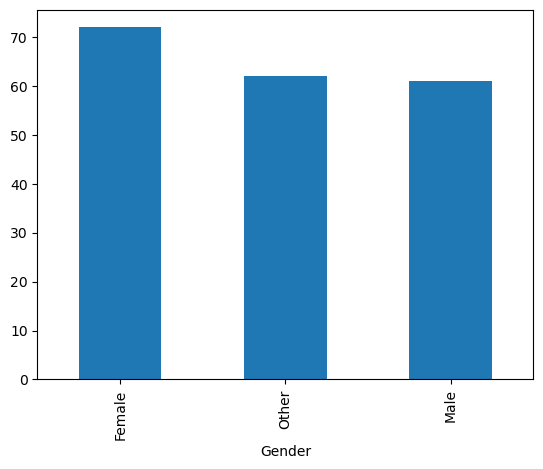

In [51]:
# bar chart showing the distribution of gender.
df['Gender'].value_counts().plot(kind='bar')
plt.show()

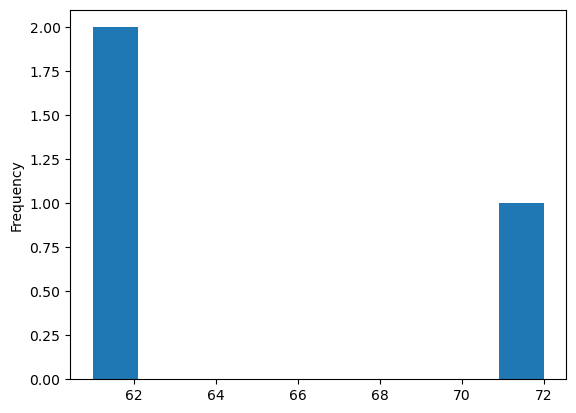

In [52]:
# histogram showing the distribution of BMI values.
df['Gender'].value_counts().plot(kind='hist')
plt.show()

<Axes: xlabel='Age'>

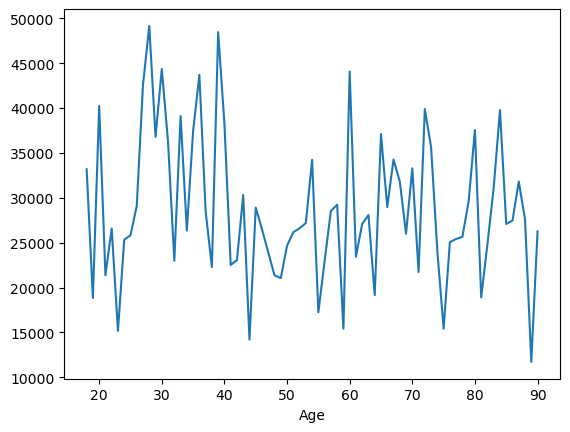

In [53]:
# line chart of average Treatment_Cost by Age.
df.groupby("Age")["Treatment_Cost"].mean().plot(kind="line")

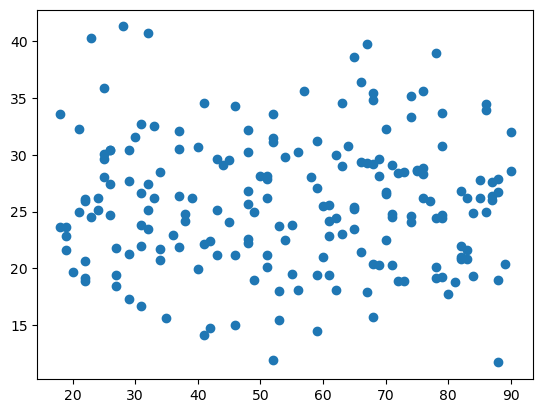

In [54]:
# scatter plot of Age vs BMI.
plt.scatter(df["Age"],df["BMI"])

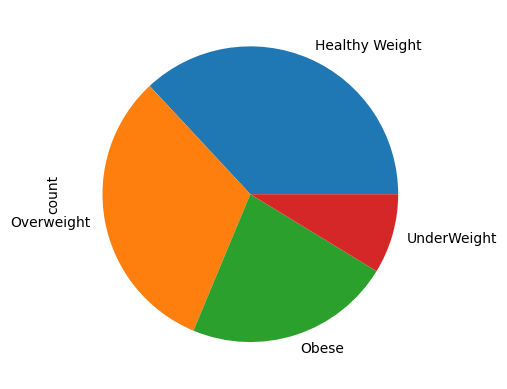

In [55]:
# Pie of BMI categories
df['BMI_Category'].value_counts().plot(kind='pie')
plt.show()

In [56]:
# top 5 patients with the highest Treatment_Cost.
df.sort_values(by="Treatment_Cost", ascending=False).head()


,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age
103,P1103,Lauren Wade,67.00,Female,149.70,89.20,39.80,131/91,102.00,200.00,81.30,Former,5.30,1.00,0.00,E11,War family anyone.,2025-06-18,2025-07-03,49779.42,Dr. Roy,131.00,91.00,15.00,True,Normal,True,3318.63,Overweight,False
194,P1194,Kimberly Cruz,70.00,Male,157.70,66.30,26.70,122/100,56.00,187.80,115.50,Smoker,15.20,6.00,0.00,E11,Decade value soon well.,2025-06-09,2025-06-24,49240.21,Dr. Sharma,122.00,100.00,15.00,True,Normal,True,3282.68,Overweight,False
99,P1099,Sarah Aguirre,28.00,Other,147.90,90.30,41.30,104/93,119.00,186.60,130.90,Former,11.10,6.00,0.00,E11,Yourself job speech.,2025-04-29,2025-05-10,49146.77,Dr. Sharma,104.00,93.00,11.00,True,Normal,False,4467.89,Obese,False
34,P1034,Clinton Howell,87.00,Other,157.20,65.20,26.40,131/74,89.00,214.40,69.20,Smoker,7.80,6.00,1.00,K21,Serious policy little.,2025-03-29,2025-04-07,49132.49,Dr. Kapoor,131.00,74.00,9.00,False,Normal,True,5459.17,Overweight,False
93,P1093,Todd Moore,39.00,Other,179.50,84.40,26.20,126/83,85.00,254.60,80.80,Former,5.70,7.00,1.00,M54,Must.,2025-06-18,2025-07-01,48451.85,Dr. Mehta,126.00,83.00,13.00,False,High,False,3727.07,Healthy Weight,False


In [57]:
# patients with the shortest hospital stays.
df.sort_values(by="Stay_Duration").head(5)

,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age
199,P1199,Darryl Novak,69.00,Female,164.60,80.20,29.60,135/75,67.00,190.80,100.70,Smoker,2.40,0.00,1.00,I10,Run.,2025-04-17,2025-04-18,23026.18,Dr. Sharma,135.00,75.00,1.00,False,Normal,True,23026.18,NaN,False
113,P1113,Melissa Knox,21.00,Male,155.10,77.60,32.30,141/96,88.00,174.10,80.20,Former,8.30,0.00,0.00,N18,Same require candidate.,2025-06-17,2025-06-18,33885.83,Dr. Mehta,141.00,96.00,1.00,True,Normal,False,33885.83,Healthy Weight,False
107,P1107,Veronica Hooper,41.00,Female,175.60,43.60,14.10,158/95,70.00,154.50,49.00,Non-Smoker,14.10,3.00,0.00,N18,Ok material.,2025-04-26,2025-04-27,27104.01,Dr. Sharma,158.00,95.00,1.00,True,Normal,False,27104.01,UnderWeight,False
141,P1141,Jimmy Salas,89.00,Other,177.00,63.90,20.40,158/71,109.00,128.90,74.80,Smoker,19.40,6.00,0.00,N18,Finish inside rest.,2025-06-16,2025-06-17,11714.79,Dr. Iyer,158.00,71.00,1.00,True,Normal,True,11714.79,Healthy Weight,False
96,P1096,Rita Brown,68.00,Other,157.40,72.30,29.20,124/65,102.00,200.30,146.90,Non-Smoker,18.60,5.00,1.00,I10,About this such range.,2025-06-05,2025-06-06,46282.83,Dr. Mehta,124.00,65.00,1.00,False,Normal,True,46282.83,Healthy Weight,False


In [58]:
# Sort patients by Age in descending order.
df.sort_values(by="Age", ascending=False)

,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age
35,P1035,Sherry Wells,90.00,Other,167.30,89.60,32.00,141/87,72.00,141.80,104.60,Smoker,1.00,6.00,0.00,I10,Really little trade.,2025-06-08,2025-06-18,20187.52,Dr. Roy,141.00,87.00,10.00,True,Normal,True,2018.75,Obese,False
80,P1080,Melissa Mcdowell,90.00,Other,166.00,78.90,28.60,103/69,75.00,165.50,152.30,Smoker,13.50,4.00,0.00,N18,Me child.,2025-04-22,2025-05-05,32318.42,Dr. Mehta,103.00,69.00,13.00,False,Normal,True,2486.03,Healthy Weight,False
141,P1141,Jimmy Salas,89.00,Other,177.00,63.90,20.40,158/71,109.00,128.90,74.80,Smoker,19.40,6.00,0.00,N18,Finish inside rest.,2025-06-16,2025-06-17,11714.79,Dr. Iyer,158.00,71.00,1.00,True,Normal,True,11714.79,Healthy Weight,False
43,P1043,Jesus Cruz,88.00,Female,164.20,75.10,27.90,129/77,94.00,198.30,120.70,Smoker,14.40,5.00,1.00,N18,Impact memory might.,2025-06-23,2025-06-30,39298.53,Dr. Mehta,129.00,77.00,7.00,False,Normal,True,5614.08,Overweight,False
147,P1147,Dennis Robinson,88.00,Other,173.30,57.20,19.00,121/76,117.00,192.10,88.10,Former,14.80,7.00,1.00,N18,Throughout form.,2025-04-29,2025-05-07,12616.96,Dr. Kapoor,121.00,76.00,8.00,False,Normal,True,1577.12,Healthy Weight,False
71,P1071,Mitchell Schmidt,88.00,Male,186.30,40.70,11.70,152/74,97.00,185.40,114.70,Former,0.10,2.00,1.00,M54,Study century anyone.,2025-04-23,2025-05-07,12852.37,Dr. Sharma,152.00,74.00,14.00,True,Normal,True,918.03,Healthy Weight,False
14,P1014,Troy Vang,88.00,Male,156.60,65.40,26.70,134/60,66.00,199.90,124.40,Smoker,3.30,7.00,0.00,I10,Past develop.,2025-05-04,2025-05-17,45609.93,Dr. Sharma,134.00,60.00,13.00,False,Normal,True,3508.46,Overweight,False
34,P1034,Clinton Howell,87.00,Other,157.20,65.20,26.40,131/74,89.00,214.40,69.20,Smoker,7.80,6.00,1.00,K21,Serious policy little.,2025-03-29,2025-04-07,49132.49,Dr. Kapoor,131.00,74.00,9.00,False,Normal,True,5459.17,Overweight,False
148,P1148,Cynthia Salinas,87.00,Other,169.80,75.00,26.00,133/62,64.00,221.10,87.20,Former,1.00,0.00,0.00,I10,Impact.,2025-05-14,2025-05-17,15414.50,Dr. Sharma,133.00,62.00,3.00,False,Normal,True,5138.17,Healthy Weight,False
50,P1050,Vanessa Figueroa,87.00,Female,168.60,78.40,27.60,138/62,110.00,222.50,126.30,Former,5.00,1.00,1.00,N18,Democrat meet doctor.,2025-06-03,2025-06-12,30883.96,Dr. Roy,138.00,62.00,9.00,False,Normal,True,3431.55,Overweight,False


In [59]:
# crosstab of Gender vs Smoking_Status.
pd.crosstab(df["Gender"],df["Smoking_Status"])


Smoking_Status,Former,Non-Smoker,Smoker
Gender,,,
Female,32,22,18
Male,32,14,15
Other,25,15,22


In [60]:
# pivot table showing average Treatment_Cost by Gender and Smoking_Status.
#pd.pivot_table(data, index, columns, values, aggfunc, fill_value, margins)

pd.pivot_table(data=df, index="Gender", columns="Smoking_Status", values="Treatment_Cost", aggfunc=np.mean)

Smoking_Status,Former,Non-Smoker,Smoker
Gender,,,
Female,28514.12,26358.94,24844.54
Male,27279.29,34277.82,36658.94
Other,26901.01,26685.65,26241.51


In [61]:
# Count the number of words in each Prescription.
df['Prescription_Word_Count'] = df['Prescription'].apply(lambda x: len(str(x).split()))


In [62]:
# Filter prescriptions with 'pain'
for i in df.Prescription:
    if "pain" in str(i):
        print(i)
    

In [63]:
# Extract the month from Admission_Date.
df["Admission_month"]=df["Admission_Date"].dt.month

In [64]:
# Count the number of admissions for each month.
df["Admission_month"].value_counts()

Admission_month
6.00    63
5.00    62
4.00    61
3.00     9
Name: count, dtype: int64

In [65]:
# patients aged 30–50 with Blood_Sugar levels over 120.
df[(((df["Age"]>=30) & (df["Age"]<=50)) & (df["Blood_Sugar_mg/dL"]>120))] 

,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age,Prescription_Word_Count,Admission_month
0,P1000,Matthew Ford,32.00,Male,170.00,67.90,23.50,115/74,72.00,209.40,138.10,Former,14.80,1.00,0.00,E11,About this such range.,2025-04-01,2025-04-12,14838.71,Dr. Sharma,115.00,74.00,11.00,False,Normal,False,1348.97,Healthy Weight,False,4,4.00
11,P1011,Janet Hernandez,33.00,Male,150.20,59.20,26.20,121/61,84.00,176.20,126.40,Smoker,1.40,0.00,1.00,E11,Physical deal machine.,2025-05-09,2025-05-17,43683.59,Dr. Sharma,121.00,61.00,8.00,False,Normal,False,5460.45,Overweight,False,3,5.00
13,P1013,Michele Hughes,30.00,Male,158.20,79.20,31.60,121/66,86.00,220.90,123.30,Former,9.00,6.00,1.00,J45,Well employee.,2025-05-14,2025-05-25,44351.87,Dr. Sharma,121.00,66.00,11.00,False,Normal,False,4031.99,Obese,False,2,5.00
22,P1022,Deanna Howell,37.00,Male,159.70,77.70,30.50,151/71,107.00,192.90,124.20,Former,14.70,5.00,0.00,N18,Good future.,2025-05-17,2025-05-27,41483.72,Dr. Sharma,151.00,71.00,10.00,True,Normal,False,4148.37,Obese,False,2,5.00
112,P1112,Courtney Stevens,43.00,Other,159.90,54.10,21.20,117/68,93.00,188.10,123.90,Smoker,10.10,2.00,1.00,I10,Or military test.,2025-04-11,2025-04-16,37428.47,Dr. Iyer,117.00,68.00,5.00,False,Normal,False,7485.69,Healthy Weight,False,3,4.00
142,P1142,Lauren Wilkerson,48.00,Male,146.30,64.70,30.20,145/69,114.00,190.60,141.90,Former,8.30,6.00,1.00,K21,Article recognize star cup.,2025-04-27,2025-05-05,14150.15,Dr. Kapoor,145.00,69.00,8.00,True,Normal,False,1768.77,Overweight,False,4,4.00
144,P1144,Casey Flores,44.00,Female,167.40,81.60,29.10,158/60,82.00,145.60,128.60,Former,2.30,7.00,1.00,N18,Go member bit create.,2025-06-22,2025-06-30,14203.09,Dr. Iyer,158.00,60.00,8.00,True,Normal,False,1775.39,Overweight,False,4,6.00
169,P1169,James Beltran,32.00,Female,153.90,96.30,40.70,129/99,77.00,218.10,131.80,Former,16.00,1.00,1.00,J45,Money senior market.,2025-04-21,2025-05-01,18742.10,Dr. Mehta,129.00,99.00,10.00,True,Normal,False,1874.21,Obese,False,3,4.00


In [66]:
# Save the cleaned dataset to a new CSV file.
df.to_csv("cleaned_healthcare_dataset.csv",index=False)

In [67]:
df["Gender"]

0        Male
1       Other
2      Female
3       Other
4       Other
5      Female
6      Female
7       Other
8       Other
9      Female
10      Other
11       Male
12      Other
13       Male
14       Male
15     Female
16      Other
17       Male
18       Male
19       Male
20     Female
21      Other
22       Male
23     Female
24     Female
25     Female
26       Male
27      Other
28      Other
29     Female
30       Male
31      Other
32     Female
33     Female
34      Other
35      Other
36     Female
37       Male
38     Female
39       Male
40     Female
41     Female
42      Other
43     Female
44     Female
45      Other
46     Female
47     Female
48       Male
49     Female
50     Female
51       Male
53       Male
54      Other
55     Female
56     Female
57      Other
58      Other
59      Other
60     Female
61     Female
62     Female
63       Male
64     Female
65       Male
66       Male
67      Other
68       Male
69     Female
70       Male
71       Male
72    

In [68]:
# Replace 'Other' in Gender with NaN.
df["Gender"]= df["Gender"].apply(lambda x:None if x=="Other" else x)


In [69]:
df["Gender"]

0        Male
1        None
2      Female
3        None
4        None
5      Female
6      Female
7        None
8        None
9      Female
10       None
11       Male
12       None
13       Male
14       Male
15     Female
16       None
17       Male
18       Male
19       Male
20     Female
21       None
22       Male
23     Female
24     Female
25     Female
26       Male
27       None
28       None
29     Female
30       Male
31       None
32     Female
33     Female
34       None
35       None
36     Female
37       Male
38     Female
39       Male
40     Female
41     Female
42       None
43     Female
44     Female
45       None
46     Female
47     Female
48       Male
49     Female
50     Female
51       Male
53       Male
54       None
55     Female
56     Female
57       None
58       None
59       None
60     Female
61     Female
62     Female
63       Male
64     Female
65       Male
66       Male
67       None
68       Male
69     Female
70       Male
71       Male
72    

In [70]:
# 73. Strip leading/trailing whitespace from Doctor_Assigned column
df["Doctor_Assigned"]=df["Doctor_Assigned"].str.strip()

In [71]:
# Alcohol_Abuse flag for patients consuming over 14 units per week.
df["Alcohol_Abuse_Flag"]=df["Alcohol_Consumption"].apply(lambda x:"Y" if x>14 else "N")

In [72]:
#75 Retrieve names of female diabetic patients over 50.
df[((df["Diabetes_Status"]==1) & (df["Gender"]=="Female") & (df["Age"]>50))]


,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age,Prescription_Word_Count,Admission_month,Alcohol_Abuse_Flag
6,P1006,Melissa Taylor,69.00,Female,159.60,71.70,28.10,108/92,118.00,155.50,109.40,Former,0.90,1.00,1.00,N18,Bill star.,2025-06-06,2025-06-13,35621.65,Dr. Kapoor,108.00,92.00,7.00,True,Normal,True,5088.81,Overweight,False,2,6.00,N
9,P1009,Joshua Burgess,59.00,Female,167.10,40.60,14.50,159/83,94.00,150.20,104.90,Smoker,17.60,1.00,1.00,N18,Democratic drive consumer.,2025-06-24,2025-07-04,8114.56,Dr. Mehta,159.00,83.00,10.00,True,Normal,False,811.46,UnderWeight,False,3,6.00,Y
15,P1015,Donald Williams,51.00,Female,160.20,67.20,26.20,144/95,117.00,156.80,70.10,Non-Smoker,4.40,0.00,1.00,N18,Somebody home relationship.,2025-03-27,2025-04-03,7256.41,Dr. Iyer,144.00,95.00,7.00,True,Normal,False,1036.63,Overweight,False,3,3.00,N
20,P1020,Marisa Garcia,72.00,Female,162.80,75.40,28.40,121/68,88.00,234.30,87.00,Non-Smoker,11.00,6.00,1.00,E11,Management play.,2025-04-02,2025-04-04,44739.79,Dr. Iyer,121.00,68.00,2.00,False,Normal,True,22369.90,Overweight,False,2,4.00,N
24,P1024,Nicholas Powers,83.00,Female,168.00,73.90,26.20,153/94,97.00,190.20,94.10,Smoker,17.50,4.00,1.00,M54,None something interesting office.,2025-05-12,2025-05-23,16945.99,Dr. Kapoor,153.00,94.00,11.00,True,Normal,True,1540.54,Overweight,False,4,5.00,Y
25,P1025,Seth Cobb,58.00,Female,150.80,63.70,28.00,132/67,104.00,179.70,79.90,Smoker,5.10,6.00,1.00,M54,Mind say feel late.,2025-04-10,2025-04-16,29230.34,Dr. Mehta,132.00,67.00,6.00,False,Normal,False,4871.72,Overweight,False,4,4.00,N
36,P1036,Daniel Davis,71.00,Female,167.60,81.70,29.10,130/61,61.00,152.90,67.00,Non-Smoker,4.50,1.00,1.00,E11,Message keep.,2025-04-23,2025-05-06,13971.23,Dr. Sharma,130.00,61.00,13.00,False,Normal,True,1074.71,Overweight,False,2,4.00,N
38,P1038,Stephanie Kim,66.00,Female,158.20,73.50,29.40,112/64,86.00,198.80,82.10,Non-Smoker,17.00,1.00,1.00,J45,Should light determine.,2025-04-05,2025-04-10,34768.46,Dr. Sharma,112.00,64.00,5.00,False,Normal,True,6953.69,Overweight,False,3,4.00,Y
43,P1043,Jesus Cruz,88.00,Female,164.20,75.10,27.90,129/77,94.00,198.30,120.70,Smoker,14.40,5.00,1.00,N18,Impact memory might.,2025-06-23,2025-06-30,39298.53,Dr. Mehta,129.00,77.00,7.00,False,Normal,True,5614.08,Overweight,False,3,6.00,Y
44,P1044,Jeffrey Snyder,79.00,Female,165.10,91.80,33.70,148/93,91.00,182.10,168.00,Smoker,5.90,5.00,1.00,J45,About this such range.,2025-05-11,2025-05-23,29036.08,Dr. Sharma,148.00,93.00,12.00,True,Normal,True,2419.67,Obese,False,4,5.00,N


In [73]:
df["BMI"]

0     23.50
1     25.10
2     30.40
3     14.70
4     31.10
5     20.60
6     28.10
7     25.90
8     19.90
9     14.50
10    24.40
11    26.20
12    15.40
13    31.60
14    26.70
15    26.20
16    30.10
17    21.20
18    34.50
19    23.80
20    28.40
21    25.40
22    30.50
23    26.10
24    26.20
25    28.00
26    28.50
27    24.50
28    39.00
29    19.40
30    18.90
31    35.20
32    22.60
33    32.30
34    26.40
35    32.00
36    29.10
37    25.70
38    29.40
39    22.80
40    33.90
41    25.00
42    22.20
43    27.90
44    33.70
45    19.50
46    30.40
47    19.30
48    18.40
49    29.60
50    27.60
51    24.50
53    26.20
54    26.80
55    11.90
56    33.60
57    32.20
58    22.00
59    34.80
60    27.70
61    27.80
62    22.80
63    24.70
64    18.80
65    28.50
66    19.40
67    27.90
68    22.50
69    21.90
70    29.00
71    11.70
72    21.60
73    32.70
74    24.60
75    25.10
76    26.40
77    23.00
78    27.40
79    22.10
80    28.60
81    21.60
82    27.10
83    21.80
84  

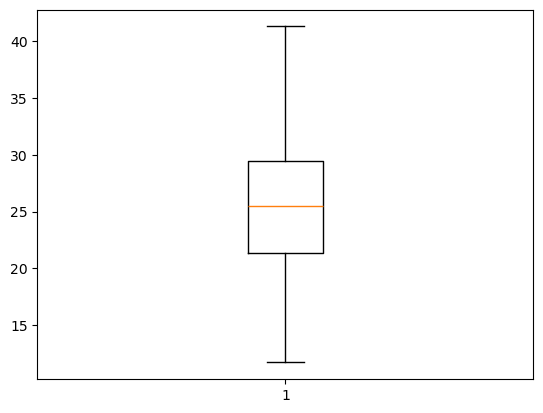

In [74]:
# boxplot of BMI values.
plt.boxplot(df["BMI"].dropna())
plt.show()

In [75]:
df.columns

Index(['Patient_ID', 'Name', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Blood_Pressure', 'Heart_Rate', 'Cholesterol_Level', 'Blood_Sugar_mg/dL', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity', 'Diabetes_Status', 'Diagnosis_Code', 'Prescription', 'Admission_Date', 'Discharge_Date', 'Treatment_Cost', 'Doctor_Assigned', 'Systolic', 'Diastolic', 'Stay_Duration', 'High_BP', 'Cholestrol_category', 'Flag_age', 'Cost_per_day', 'BMI_Category', 'Flag_Dia_Chol_Age', 'Prescription_Word_Count', 'Admission_month', 'Alcohol_Abuse_Flag'], dtype='object')

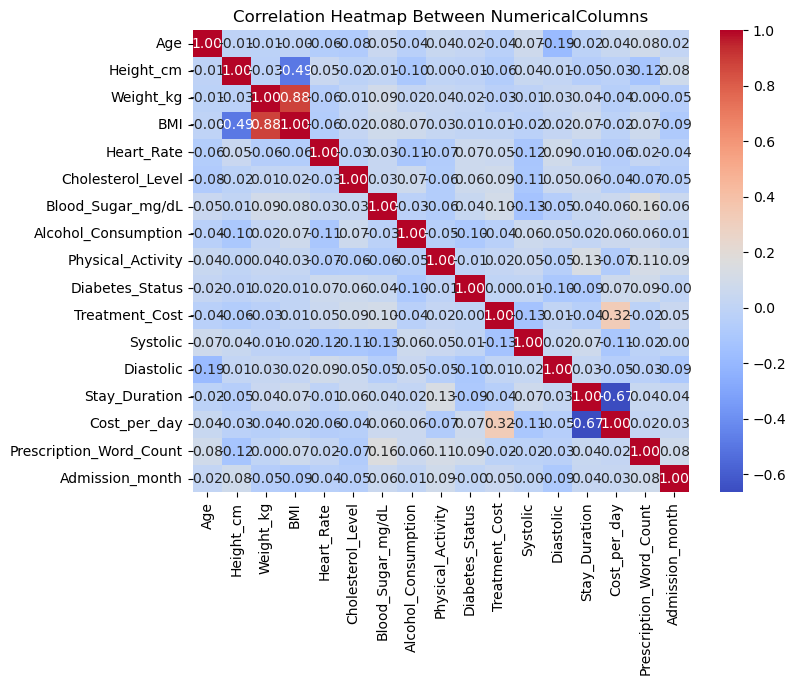

In [76]:
# 77 Generate a correlation heatmap of numeric features.
df2=pd.DataFrame()
for i in df.columns:
    if ((df[i].dtype=="int") or (df[i].dtype=="float")):
        df2[i]=df[i]

corr_matrix = df2.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap Between NumericalColumns')
plt.show()



In [77]:
df.dtypes

Patient_ID                         object
Name                               object
Age                               float64
Gender                             object
Height_cm                         float64
Weight_kg                         float64
BMI                               float64
Blood_Pressure                     object
Heart_Rate                        float64
Cholesterol_Level                 float64
Blood_Sugar_mg/dL                 float64
Smoking_Status                     object
Alcohol_Consumption               float64
Physical_Activity                 float64
Diabetes_Status                   float64
Diagnosis_Code                     object
Prescription                       object
Admission_Date             datetime64[ns]
Discharge_Date             datetime64[ns]
Treatment_Cost                    float64
Doctor_Assigned                    object
Systolic                          float64
Diastolic                         float64
Stay_Duration                     

(array([15., 18., 21., 22., 18., 20., 20., 17., 27., 17.]),
 array([ 5233.79 ,  9688.353, 14142.916, 18597.479, 23052.042, 27506.605,
        31961.168, 36415.731, 40870.294, 45324.857, 49779.42 ]),
 <BarContainer object of 10 artists>)

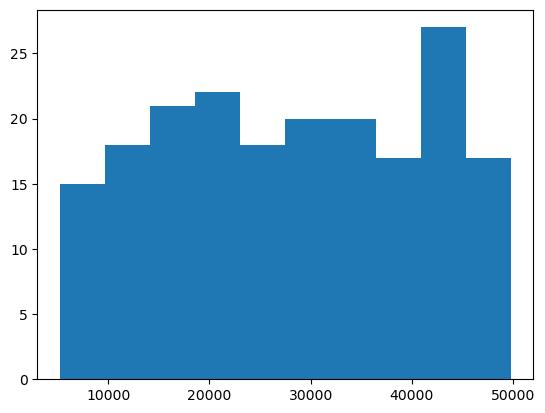

In [78]:
# Plot a histogram of Treatment_Cost.
plt.hist(df["Treatment_Cost"])

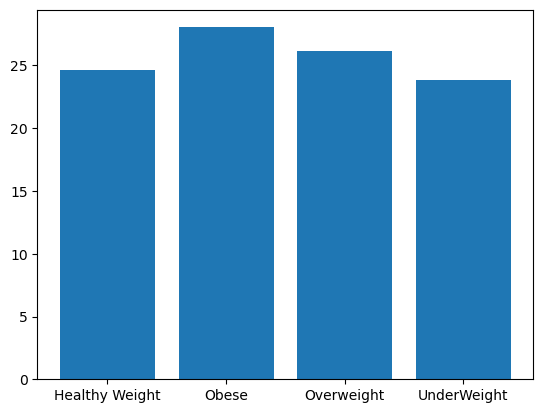

In [79]:
# Create a bar chart showing average BMI by category.
c=df.groupby("BMI_Category")["BMI"].mean()
plt.bar(c.index,c.values)
plt.show()

In [80]:
df["Age_Categories"]=pd.cut(df["Age"].dropna(),[10,20,30,40,50,60,70,80,90],
                           labels=["10-20","20-30","30- 40", "40- 50", "50- 60", "60-70", "70-80", "80-90"])
df["Age_Categories"]

0      30- 40
1      40- 50
2       20-30
3      40- 50
4      50- 60
5       20-30
6       60-70
7       70-80
8      30- 40
9      50- 60
10      70-80
11     30- 40
12     50- 60
13      20-30
14      80-90
15     50- 60
16      20-30
17     50- 60
18      80-90
19     30- 40
20      70-80
21      60-70
22     30- 40
23      20-30
24      80-90
25     50- 60
26      70-80
27      70-80
28      70-80
29      20-30
30      70-80
31      70-80
32     40- 50
33      60-70
34      80-90
35      80-90
36      70-80
37     40- 50
38      60-70
39      60-70
40      80-90
41      20-30
42     40- 50
43      80-90
44      70-80
45     50- 60
46      20-30
47      80-90
48      20-30
49     40- 50
50      80-90
51      20-30
53      20-30
54     40- 50
55     50- 60
56      10-20
57     40- 50
58      80-90
59      60-70
60      20-30
61      80-90
62      10-20
63      70-80
64      80-90
65     30- 40
66      60-70
67     50- 60
68      60-70
69     30- 40
70      60-70
71      80-90
72    

Age_Categories
10-20    99.83
20-30    92.32
30- 40   85.28
40- 50   87.91
50- 60   92.00
60-70    87.94
70-80    87.86
80-90    86.64
Name: Heart_Rate, dtype: float64


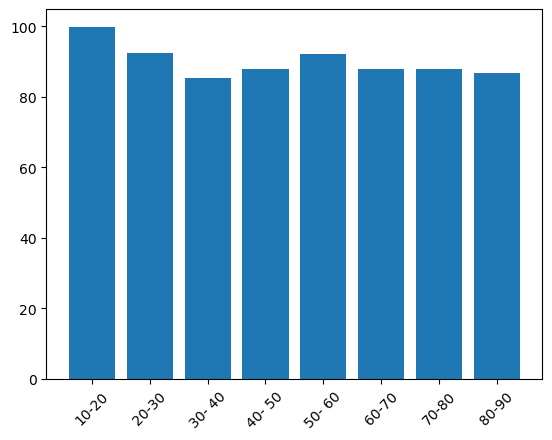

In [81]:
#80 Plot a line chart of average Heart_Rate across Age groups.
c=df.groupby("Age_Categories")["Heart_Rate"].mean()
print(c)
plt.bar(c.index,c.values)
plt.xticks(rotation=45)
plt.show()

In [82]:
df

,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age,Prescription_Word_Count,Admission_month,Alcohol_Abuse_Flag,Age_Categories
0,P1000,Matthew Ford,32.00,Male,170.00,67.90,23.50,115/74,72.00,209.40,138.10,Former,14.80,1.00,0.00,E11,About this such range.,2025-04-01,2025-04-12,14838.71,Dr. Sharma,115.00,74.00,11.00,False,Normal,False,1348.97,Healthy Weight,False,4,4.00,Y,30- 40
1,P1001,Diamond Duffy,43.00,None,162.70,66.50,25.10,134/86,83.00,237.40,119.20,Non-Smoker,16.20,0.00,1.00,N18,Financial garden program.,2025-03-29,2025-04-07,17504.21,Dr. Roy,134.00,86.00,9.00,False,Normal,False,1944.91,Overweight,False,3,3.00,Y,40- 50
2,P1002,Jessica Franklin,29.00,Female,160.30,78.10,30.40,154/82,88.00,176.10,88.40,Former,9.20,1.00,0.00,E11,Candidate black hold.,2025-04-08,2025-04-10,42323.21,Dr. Roy,154.00,82.00,2.00,True,Normal,False,21161.60,Obese,False,3,4.00,N,20-30
3,P1003,Amber Patterson,42.00,None,167.40,41.30,14.70,142/74,92.00,138.30,85.90,Smoker,17.30,6.00,0.00,K21,Project wide.,2025-04-27,2025-05-07,21417.45,Dr. Mehta,142.00,74.00,10.00,True,Normal,False,2141.74,UnderWeight,False,2,4.00,Y,40- 50
4,P1004,Michael Reyes,52.00,None,154.90,74.70,31.10,141/64,76.00,162.80,64.70,Smoker,3.30,6.00,0.00,N18,Window college name.,2025-06-04,2025-06-15,14882.68,Dr. Sharma,141.00,64.00,11.00,True,Normal,False,1352.97,Obese,False,3,6.00,N,50- 60
5,P1005,Cheryl Wright,22.00,Female,179.70,66.60,20.60,104/73,95.00,192.00,64.40,Non-Smoker,7.90,7.00,1.00,J45,Skill.,2025-05-04,2025-05-08,38524.50,Dr. Iyer,104.00,73.00,4.00,False,Normal,False,9631.12,Healthy Weight,False,1,5.00,N,20-30
6,P1006,Melissa Taylor,69.00,Female,159.60,71.70,28.10,108/92,118.00,155.50,109.40,Former,0.90,1.00,1.00,N18,Bill star.,2025-06-06,2025-06-13,35621.65,Dr. Kapoor,108.00,92.00,7.00,True,Normal,True,5088.81,Overweight,False,2,6.00,N,60-70
7,P1007,Colin Robinson,77.00,None,159.00,65.60,25.90,135/60,69.00,171.90,146.30,Former,15.00,5.00,1.00,J45,Professional blood.,2025-06-13,2025-06-20,25417.57,Dr. Roy,135.00,60.00,7.00,False,Normal,True,3631.08,Overweight,False,2,6.00,Y,70-80
8,P1008,Jordan Baker,40.00,None,164.90,54.10,19.90,155/100,93.00,214.70,69.50,Former,12.20,2.00,0.00,I10,South likely.,2025-05-02,2025-05-11,40038.19,Dr. Sharma,155.00,100.00,9.00,True,Normal,False,4448.69,Healthy Weight,False,2,5.00,N,30- 40
9,P1009,Joshua Burgess,59.00,Female,167.10,40.60,14.50,159/83,94.00,150.20,104.90,Smoker,17.60,1.00,1.00,N18,Democratic drive consumer.,2025-06-24,2025-07-04,8114.56,Dr. Mehta,159.00,83.00,10.00,True,Normal,False,811.46,UnderWeight,False,3,6.00,Y,50- 60


In [83]:
df["Age"].max()

90.0

Text(0, 0.5, 'Height')

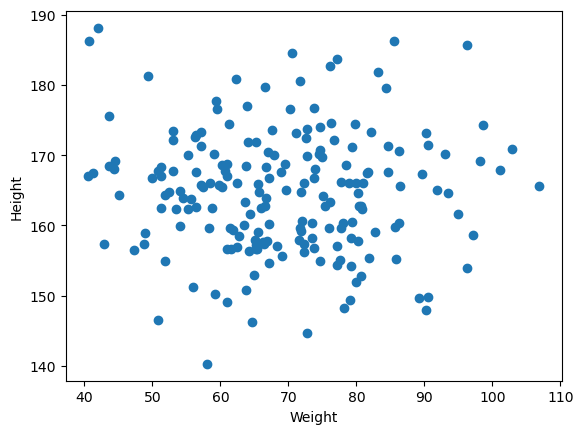

In [84]:
# Create a scatter plot of Weight vs Height.
plt.scatter(df["Weight_kg"],df["Height_cm"])
plt.xlabel("Weight")
plt.ylabel("Height")

<BarContainer object of 133 artists>

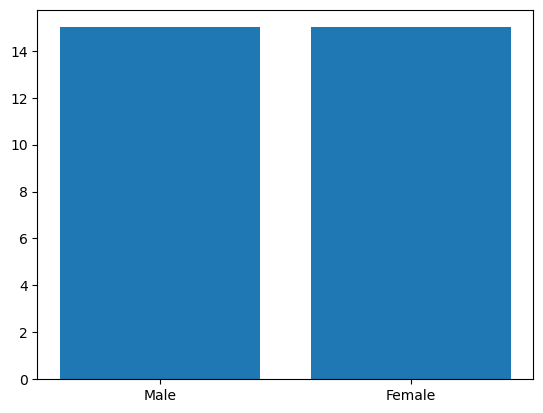

In [85]:
# Plot a bar chart of average Stay_Duration by Gender.
clean_data=df.dropna(subset=["Gender","Stay_Duration"])
plt.bar(clean_data["Gender"],clean_data["Stay_Duration"])


In [86]:
# Display a bar chart of the top 10 doctors by patient count.
df["Doctor_Assigned"].value_counts().head(10)

Doctor_Assigned
Dr. Sharma    56
Dr. Mehta     40
Dr. Roy       35
Dr. Iyer      34
Dr. Kapoor    30
Name: count, dtype: int64

<Axes: xlabel='Smoking_Status', ylabel='count'>

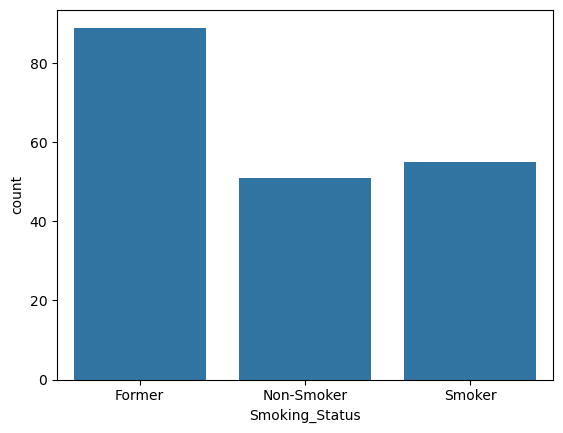

In [87]:
# 84Create a countplot of Smoking_Status using Seaborn.
sns.countplot(x=df["Smoking_Status"])

<Axes: xlabel='Stay_Duration', ylabel='Count'>

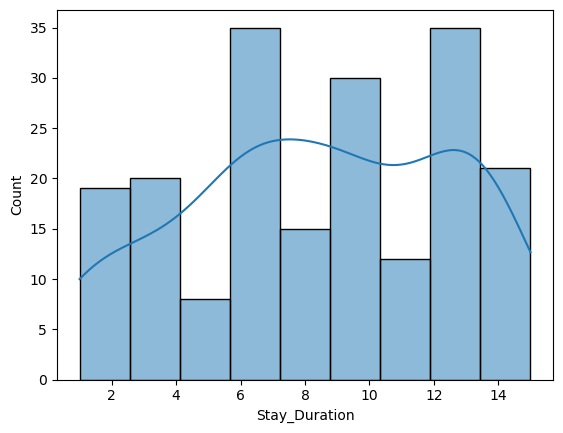

In [88]:
# Plot a histogram with KDE for Stay_Duration.
sns.histplot(df["Stay_Duration"], kde=True)

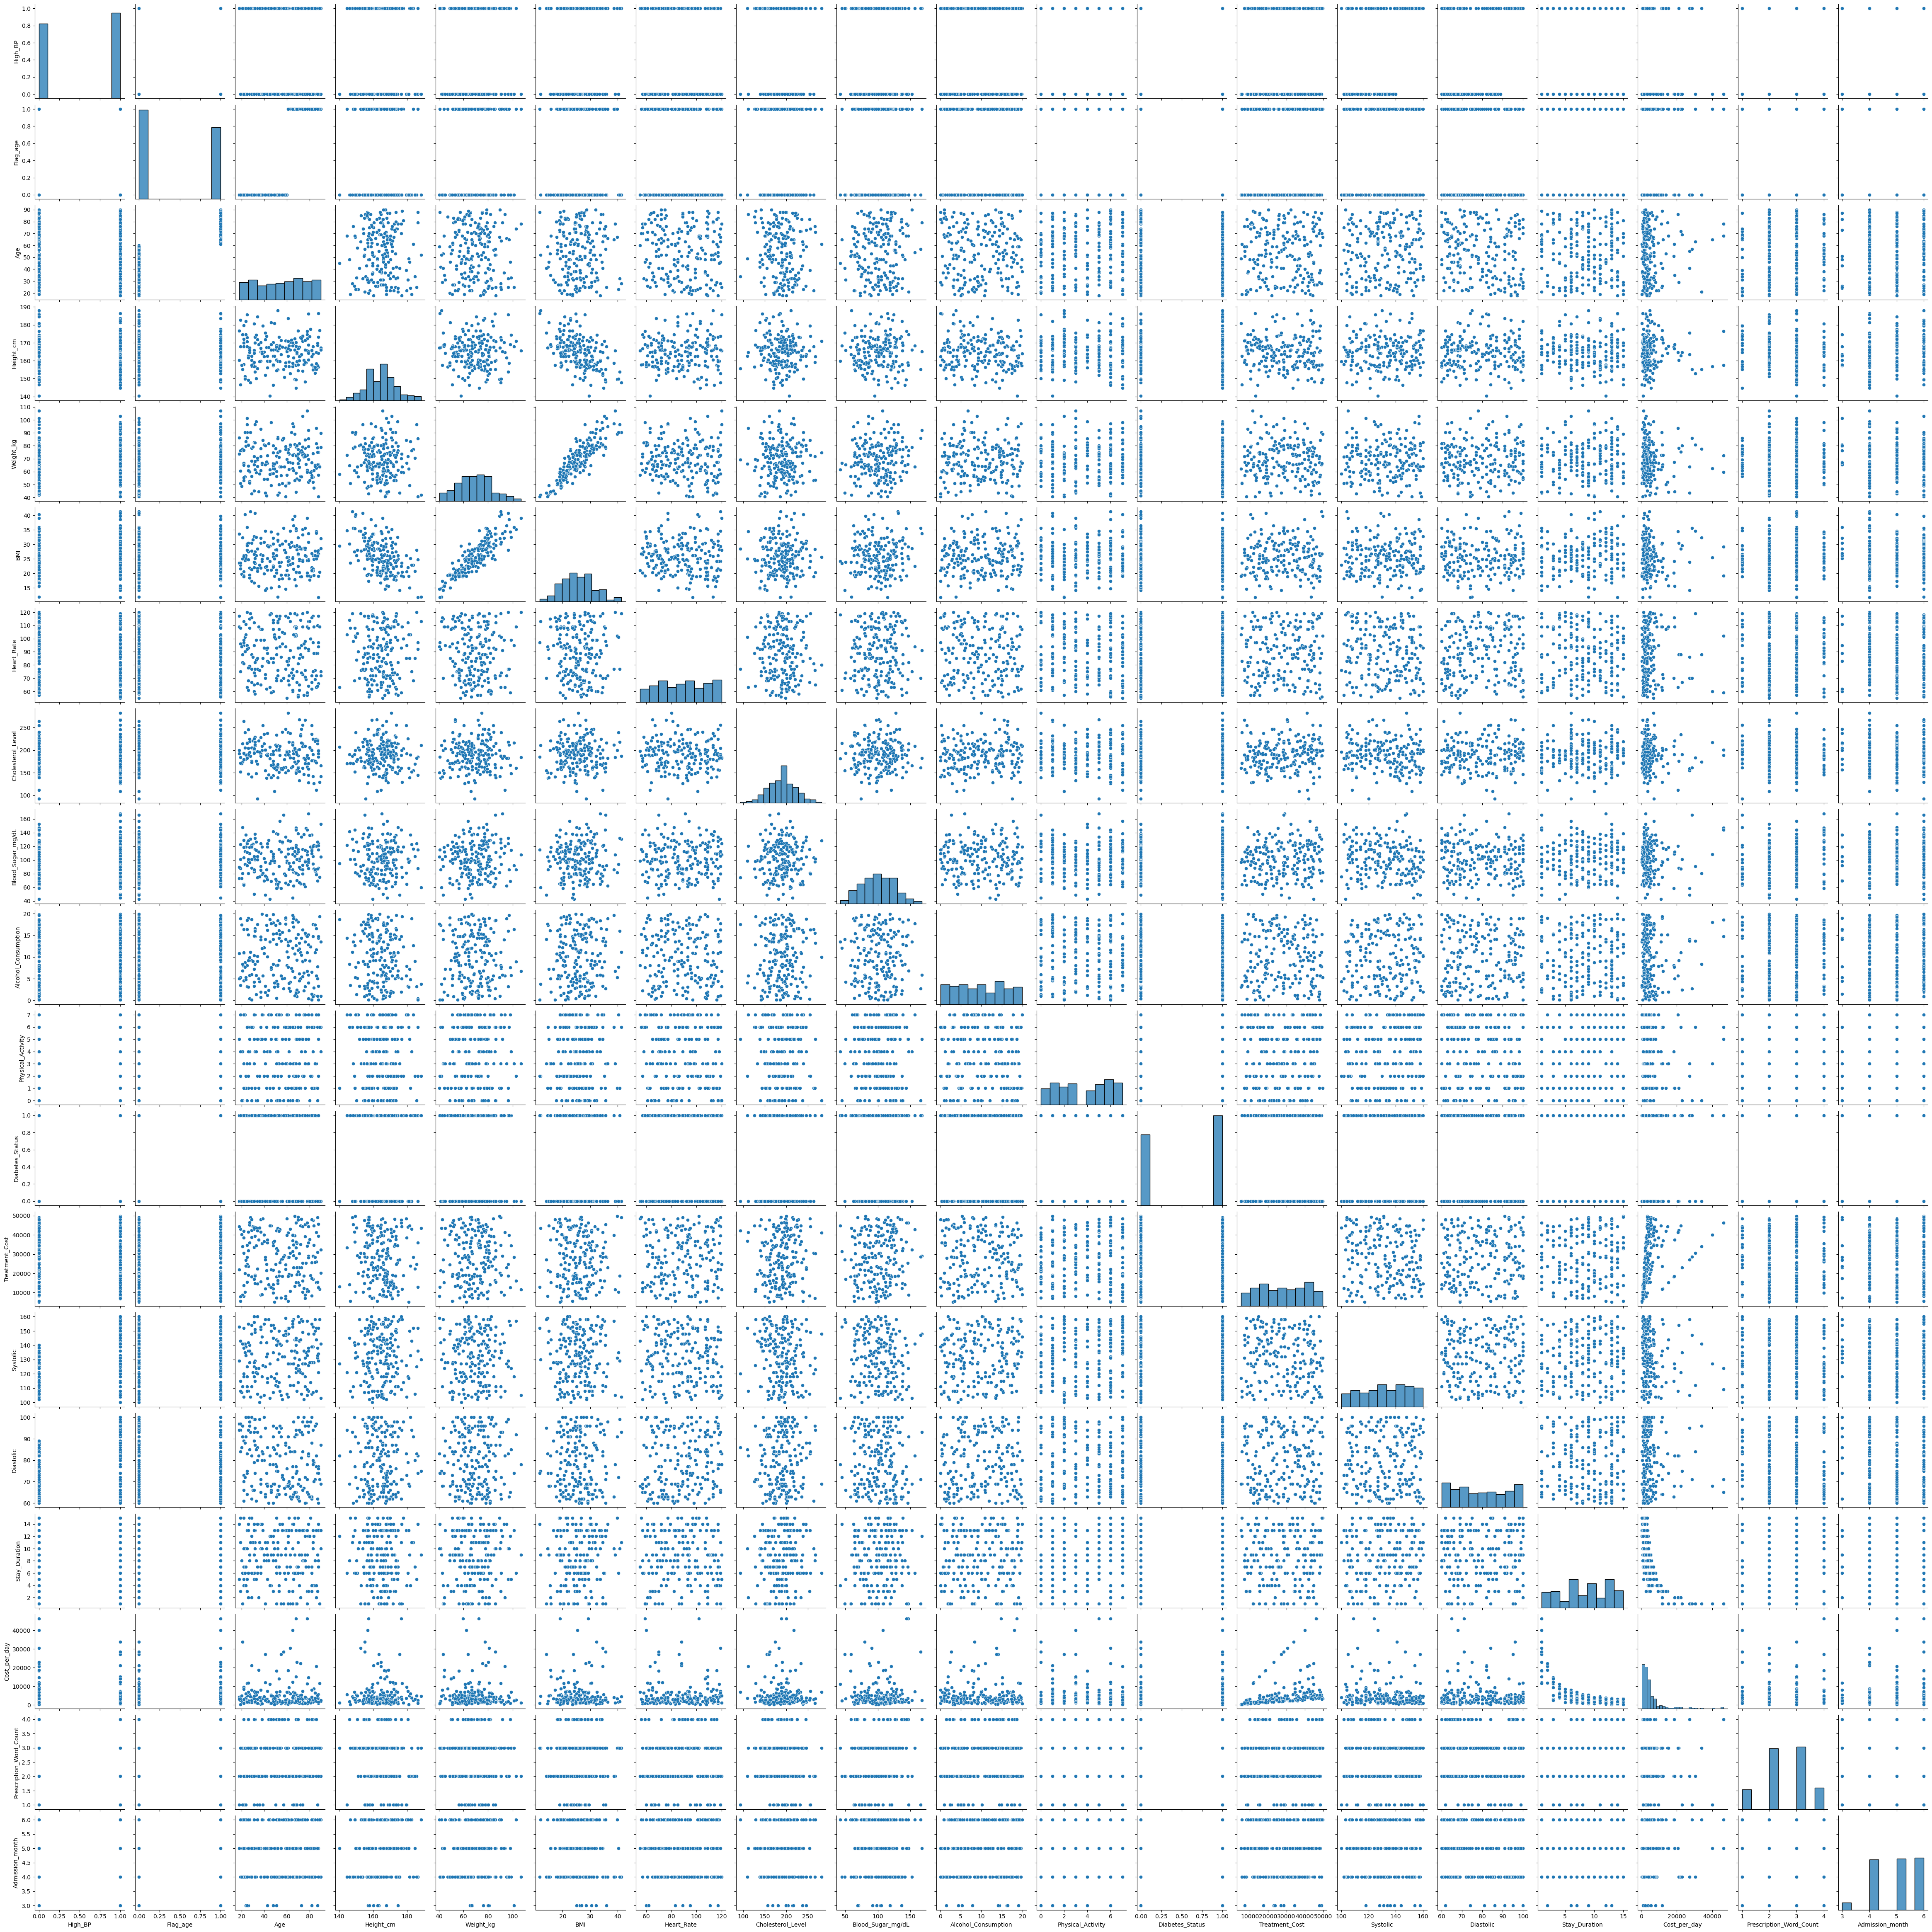

In [115]:
# Create a pairplot of selected numerical features.
# df2=pd.DataFrame()
for i in df.columns:
    if ((df[i].dtype=="int") or (df[i].dtype=="float")):
        df2[i]=df[i]
sns.pairplot(df2)

In [90]:
# Export the cleaned dataset to an Excel file.
df.to_excel("healthcare_cleaned_1.xlsx", index=False)

In [91]:
# Export the dataset to JSON format.
df.to_json("Healthcare_cleaned_1.json", orient="records")

In [92]:
# Check if any columns have more than 50% missing values.
for i in df.columns:
    if ((df[i].isnull().sum()*100/len(df[i]))>50):
        print(df[i])

In [93]:
# Display dataset summary using .info().
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 177
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Patient_ID               195 non-null    object        
 1   Name                     195 non-null    object        
 2   Age                      195 non-null    float64       
 3   Gender                   133 non-null    object        
 4   Height_cm                195 non-null    float64       
 5   Weight_kg                195 non-null    float64       
 6   BMI                      195 non-null    float64       
 7   Blood_Pressure           195 non-null    object        
 8   Heart_Rate               195 non-null    float64       
 9   Cholesterol_Level        195 non-null    float64       
 10  Blood_Sugar_mg/dL        195 non-null    float64       
 11  Smoking_Status           195 non-null    object        
 12  Alcohol_Consumption      195 non-null    

In [94]:
# 91. Calculate the total Treatment_Cost.
df["Treatment_Cost"].sum()

np.float64(5492384.7)

In [95]:
df["Age"]

0     32.00
1     43.00
2     29.00
3     42.00
4     52.00
5     22.00
6     69.00
7     77.00
8     40.00
9     59.00
10    78.00
11    33.00
12    53.00
13    30.00
14    88.00
15    51.00
16    25.00
17    51.00
18    86.00
19    31.00
20    72.00
21    65.00
22    37.00
23    22.00
24    83.00
25    58.00
26    73.00
27    71.00
28    78.00
29    27.00
30    72.00
31    74.00
32    48.00
33    70.00
34    87.00
35    90.00
36    71.00
37    48.00
38    66.00
39    61.00
40    86.00
41    21.00
42    48.00
43    88.00
44    79.00
45    55.00
46    26.00
47    84.00
48    27.00
49    43.00
50    87.00
51    23.00
53    24.00
54    48.00
55    52.00
56    18.00
57    48.00
58    82.00
59    68.00
60    29.00
61    85.00
62    19.00
63    79.00
64    81.00
65    34.00
66    61.00
67    51.00
68    70.00
69    37.00
70    63.00
71    88.00
72    19.00
73    31.00
74    74.00
75    32.00
76    37.00
77    63.00
78    32.00
79    41.00
80    90.00
81    83.00
82    59.00
83    27.00
84  

In [96]:
# Find the average Stay_Duration for patients over 60.

old_df=df[df["Age"]>60]
old_df["Stay_Duration"].mean()




np.float64(8.32183908045977)

In [97]:
# 93 Use z-score to check for outliers in Age and BMI.
from scipy.stats import zscore
np.abs(zscore(df[["Age","BMI"]])).max()

np.float64(nan)

In [98]:
# Count missing values in Heart_Rate.
df["Heart_Rate"].isnull().sum()


np.int64(5)

In [99]:
# Display data types of each column after cleaning.
df.dtypes

Patient_ID                         object
Name                               object
Age                               float64
Gender                             object
Height_cm                         float64
Weight_kg                         float64
BMI                               float64
Blood_Pressure                     object
Heart_Rate                        float64
Cholesterol_Level                 float64
Blood_Sugar_mg/dL                 float64
Smoking_Status                     object
Alcohol_Consumption               float64
Physical_Activity                 float64
Diabetes_Status                   float64
Diagnosis_Code                     object
Prescription                       object
Admission_Date             datetime64[ns]
Discharge_Date             datetime64[ns]
Treatment_Cost                    float64
Doctor_Assigned                    object
Systolic                          float64
Diastolic                         float64
Stay_Duration                     

In [114]:
# # List unique values in categorical columns.
# df2=pd.DataFrame()
# df3=pd.DataFrame()
for i in df.columns:
    if ((df[i].dtype=="category")or (df[i].dtype=="object")):
        df2[i]=df[i]

for i in df2.columns:
    print(i, df2[i].unique())
    

Patient_ID ['P1000' 'P1001' 'P1002' 'P1003' 'P1004' 'P1005' 'P1006' 'P1007' 'P1008'
 'P1009' 'P1010' 'P1011' 'P1012' 'P1013' 'P1014' 'P1015' 'P1016' 'P1017'
 'P1018' 'P1019' 'P1020' 'P1021' 'P1022' 'P1023' 'P1024' 'P1025' 'P1026'
 'P1027' 'P1028' 'P1029' 'P1030' 'P1031' 'P1032' 'P1033' 'P1034' 'P1035'
 'P1036' 'P1037' 'P1038' 'P1039' 'P1040' 'P1041' 'P1042' 'P1043' 'P1044'
 'P1045' 'P1046' 'P1047' 'P1048' 'P1049' 'P1050' 'P1051' 'P1053' 'P1054'
 'P1055' 'P1056' 'P1057' 'P1058' 'P1059' 'P1060' 'P1061' 'P1062' 'P1063'
 'P1064' 'P1065' 'P1066' 'P1067' 'P1068' 'P1069' 'P1070' 'P1071' 'P1072'
 'P1073' 'P1074' 'P1075' 'P1076' 'P1077' 'P1078' 'P1079' 'P1080' 'P1081'
 'P1082' 'P1083' 'P1084' 'P1085' 'P1086' 'P1087' 'P1088' 'P1089' 'P1090'
 'P1091' 'P1092' 'P1093' 'P1094' 'P1095' 'P1096' 'P1097' 'P1099' 'P1100'
 'P1101' 'P1102' 'P1103' 'P1104' 'P1105' 'P1106' 'P1107' 'P1108' 'P1109'
 'P1110' 'P1111' 'P1112' 'P1113' 'P1114' 'P1115' 'P1116' 'P1117' 'P1118'
 'P1119' 'P1120' 'P1121' 'P1122' 'P1123'

In [126]:
# Find patients with multiple risk factors: BMI > 30, Smoking_Status = 'Smoker', 
# Diabetes_Status = 'Yes'.
df[(df["BMI"]>30) & (df["Smoking_Status"]=="Smoker") & (df["Diabetes_Status"]==1)]
        

,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age,Prescription_Word_Count,Admission_month,Alcohol_Abuse_Flag,Age_Categories
16,P1016,Rodney Dixon MD,25.00,None,173.10,90.30,30.10,111/64,63.00,187.80,125.10,Smoker,8.10,3.00,1.00,M54,Until region.,2025-06-23,2025-06-26,34581.79,Dr. Roy,111.00,64.00,3.00,False,Normal,False,11527.26,Obese,False,2,6.00,N,20-30
44,P1044,Jeffrey Snyder,79.00,Female,165.10,91.80,33.70,148/93,91.00,182.10,168.00,Smoker,5.90,5.00,1.00,J45,About this such range.,2025-05-11,2025-05-23,29036.08,Dr. Sharma,148.00,93.00,12.00,True,Normal,True,2419.67,Obese,False,4,5.00,N,70-80
125,P1125,Lisa Williams,33.00,None,174.30,98.60,32.50,124/85,99.00,148.00,114.10,Smoker,5.80,4.00,1.00,J45,Cultural power physical.,2025-04-16,2025-04-21,34518.74,Dr. Mehta,124.00,85.00,5.00,False,Normal,False,6903.75,Healthy Weight,False,3,4.00,N,30- 40
173,P1173,Chelsea Warren,74.00,None,154.20,79.20,33.30,127/66,86.00,207.80,92.30,Smoker,9.00,5.00,1.00,K21,Him small none.,2025-06-19,2025-07-02,10282.37,Dr. Mehta,127.00,66.00,13.00,False,Normal,True,790.95,Overweight,False,3,6.00,N,70-80


In [155]:
# Calculate the ratio of Male to Female patients.
df[df["Gender"]=="Male"].value_counts().sum()/df[df["Gender"]=="Female"].value_counts().sum()

np.float64(0.8428571428571429)

In [152]:
# Generate a report containing key healthcare metrics such as average cost, 
# median stay duration, senior citizens, obese patients, and patients at risk.
{
"average_cost": df["Treatment_Cost"].mean(),
"median_stay_duration": df["Stay_Duration"].median(),
"senior_citizens":df[df["Age"]>60].value_counts().sum()

}



{'average_cost': np.float64(28166.075384615386),
 'median_stay_duration': 9.0,
 'senior_citizens': np.int64(55)}

In [159]:
#senior citizens
df[df["Age"]>60]


,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age,Prescription_Word_Count,Admission_month,Alcohol_Abuse_Flag,Age_Categories
6,P1006,Melissa Taylor,69.00,Female,159.60,71.70,28.10,108/92,118.00,155.50,109.40,Former,0.90,1.00,1.00,N18,Bill star.,2025-06-06,2025-06-13,35621.65,Dr. Kapoor,108.00,92.00,7.00,True,Normal,True,5088.81,Overweight,False,2,6.00,N,60-70
7,P1007,Colin Robinson,77.00,None,159.00,65.60,25.90,135/60,69.00,171.90,146.30,Former,15.00,5.00,1.00,J45,Professional blood.,2025-06-13,2025-06-20,25417.57,Dr. Roy,135.00,60.00,7.00,False,Normal,True,3631.08,Overweight,False,2,6.00,Y,70-80
10,P1010,Tim Alvarez,78.00,None,172.40,72.60,24.40,133/98,109.00,186.50,92.50,Former,15.10,3.00,0.00,K21,Look same.,2025-05-04,2025-05-07,34244.51,Dr. Iyer,133.00,98.00,3.00,True,Normal,True,11414.84,Healthy Weight,False,2,5.00,Y,70-80
14,P1014,Troy Vang,88.00,Male,156.60,65.40,26.70,134/60,66.00,199.90,124.40,Smoker,3.30,7.00,0.00,I10,Past develop.,2025-05-04,2025-05-17,45609.93,Dr. Sharma,134.00,60.00,13.00,False,Normal,True,3508.46,Overweight,False,2,5.00,N,80-90
18,P1018,Michael Ingram,86.00,Male,164.60,93.50,34.50,108/82,63.00,111.40,120.50,Non-Smoker,5.70,7.00,0.00,M54,Never way future.,2025-05-03,2025-05-05,41319.50,Dr. Iyer,108.00,82.00,2.00,False,Normal,True,20659.75,Obese,False,3,5.00,N,80-90
20,P1020,Marisa Garcia,72.00,Female,162.80,75.40,28.40,121/68,88.00,234.30,87.00,Non-Smoker,11.00,6.00,1.00,E11,Management play.,2025-04-02,2025-04-04,44739.79,Dr. Iyer,121.00,68.00,2.00,False,Normal,True,22369.90,Overweight,False,2,4.00,N,70-80
21,P1021,Rodney Travis,65.00,None,156.90,62.50,25.40,127/68,60.00,217.50,108.20,Smoker,18.00,3.00,1.00,N18,Trial.,2025-05-03,2025-05-04,40105.23,Dr. Kapoor,127.00,68.00,1.00,False,Normal,True,40105.23,Overweight,False,1,5.00,Y,60-70
24,P1024,Nicholas Powers,83.00,Female,168.00,73.90,26.20,153/94,97.00,190.20,94.10,Smoker,17.50,4.00,1.00,M54,None something interesting office.,2025-05-12,2025-05-23,16945.99,Dr. Kapoor,153.00,94.00,11.00,True,Normal,True,1540.54,Overweight,False,4,5.00,Y,80-90
26,P1026,Miss Wendy Allen,73.00,Male,163.40,76.10,28.50,158/81,95.00,246.60,104.40,Smoker,14.40,4.00,0.00,N18,Like each door.,2025-03-29,2025-04-04,23108.02,Dr. Mehta,158.00,81.00,6.00,True,Normal,True,3851.34,Overweight,False,3,3.00,Y,70-80
27,P1027,Melissa Payne,71.00,None,167.60,68.90,24.50,143/71,93.00,132.40,99.30,Smoker,6.10,3.00,0.00,M54,Foreign same.,2025-05-16,2025-05-20,19501.22,Dr. Mehta,143.00,71.00,4.00,True,Normal,True,4875.31,Healthy Weight,False,2,5.00,N,70-80


In [160]:
# obese_patients
df[df["BMI_Category"]=="Obese"]


,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age,Prescription_Word_Count,Admission_month,Alcohol_Abuse_Flag,Age_Categories
2,P1002,Jessica Franklin,29.00,Female,160.30,78.10,30.40,154/82,88.00,176.10,88.40,Former,9.20,1.00,0.00,E11,Candidate black hold.,2025-04-08,2025-04-10,42323.21,Dr. Roy,154.00,82.00,2.00,True,Normal,False,21161.60,Obese,False,3,4.00,N,20-30
4,P1004,Michael Reyes,52.00,None,154.90,74.70,31.10,141/64,76.00,162.80,64.70,Smoker,3.30,6.00,0.00,N18,Window college name.,2025-06-04,2025-06-15,14882.68,Dr. Sharma,141.00,64.00,11.00,True,Normal,False,1352.97,Obese,False,3,6.00,N,50- 60
13,P1013,Michele Hughes,30.00,Male,158.20,79.20,31.60,121/66,86.00,220.90,123.30,Former,9.00,6.00,1.00,J45,Well employee.,2025-05-14,2025-05-25,44351.87,Dr. Sharma,121.00,66.00,11.00,False,Normal,False,4031.99,Obese,False,2,5.00,N,20-30
16,P1016,Rodney Dixon MD,25.00,None,173.10,90.30,30.10,111/64,63.00,187.80,125.10,Smoker,8.10,3.00,1.00,M54,Until region.,2025-06-23,2025-06-26,34581.79,Dr. Roy,111.00,64.00,3.00,False,Normal,False,11527.26,Obese,False,2,6.00,N,20-30
18,P1018,Michael Ingram,86.00,Male,164.60,93.50,34.50,108/82,63.00,111.40,120.50,Non-Smoker,5.70,7.00,0.00,M54,Never way future.,2025-05-03,2025-05-05,41319.50,Dr. Iyer,108.00,82.00,2.00,False,Normal,True,20659.75,Obese,False,3,5.00,N,80-90
22,P1022,Deanna Howell,37.00,Male,159.70,77.70,30.50,151/71,107.00,192.90,124.20,Former,14.70,5.00,0.00,N18,Good future.,2025-05-17,2025-05-27,41483.72,Dr. Sharma,151.00,71.00,10.00,True,Normal,False,4148.37,Obese,False,2,5.00,Y,30- 40
28,P1028,Renee Martin,78.00,None,165.60,106.90,39.00,105/78,120.00,184.20,107.50,Former,6.70,3.00,0.00,I10,Security already.,2025-04-15,2025-04-24,11630.93,Dr. Sharma,105.00,78.00,9.00,False,Normal,True,1292.33,Obese,False,2,4.00,N,70-80
31,P1031,James Bernard,74.00,None,170.90,102.90,35.20,157/92,109.00,160.30,85.80,Former,8.90,2.00,0.00,K21,Capital hold.,2025-06-05,2025-06-11,16125.79,Dr. Iyer,157.00,92.00,6.00,True,Normal,True,2687.63,Obese,False,2,6.00,N,70-80
33,P1033,Michael Welch,70.00,Female,154.40,77.10,32.30,126/63,81.00,162.40,138.70,Non-Smoker,18.10,0.00,0.00,K21,About this such range.,2025-06-22,2025-06-29,20829.15,Dr. Kapoor,126.00,63.00,7.00,False,Normal,True,2975.59,Obese,False,4,6.00,Y,60-70
35,P1035,Sherry Wells,90.00,None,167.30,89.60,32.00,141/87,72.00,141.80,104.60,Smoker,1.00,6.00,0.00,I10,Really little trade.,2025-06-08,2025-06-18,20187.52,Dr. Roy,141.00,87.00,10.00,True,Normal,True,2018.75,Obese,False,3,6.00,N,80-90


In [161]:
# patients_at_risk
df[df["Flag_Dia_Chol_Age"]==True]


,Patient_ID,Name,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Blood_Sugar_mg/dL,Smoking_Status,Alcohol_Consumption,Physical_Activity,Diabetes_Status,Diagnosis_Code,Prescription,Admission_Date,Discharge_Date,Treatment_Cost,Doctor_Assigned,Systolic,Diastolic,Stay_Duration,High_BP,Cholestrol_category,Flag_age,Cost_per_day,BMI_Category,Flag_Dia_Chol_Age,Prescription_Word_Count,Admission_month,Alcohol_Abuse_Flag,Age_Categories
119,P1119,Frederick Alvarez,61.00,None,170.80,74.70,25.60,148/69,80.00,282.40,128.00,Non-Smoker,10.00,0.00,1.00,I10,Color arm certain.,2025-04-21,2025-04-27,41178.46,Dr. Mehta,148.00,69.00,6.00,True,High,True,6863.08,Healthy Weight,True,3,4.00,N,60-70
163,P1163,Michael Rose,71.00,None,162.30,53.40,20.30,123/94,65.00,267.20,101.50,Smoker,13.20,5.00,1.00,N18,Serve stage.,2025-06-13,2025-06-22,30344.91,Dr. Kapoor,123.00,94.00,9.00,True,High,True,3371.66,Overweight,True,2,6.00,N,70-80
190,P1190,Monica Lam,76.00,None,159.20,71.80,28.30,131/96,76.00,266.80,97.60,Non-Smoker,15.50,1.00,1.00,N18,Hold fact.,2025-04-01,2025-04-09,6981.71,Dr. Mehta,131.00,96.00,8.00,True,High,True,872.71,UnderWeight,True,2,4.00,Y,70-80
